Univariate -> filling value using only the specific col <br>
Bivariate -> filling value using neighbouring cols

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('titanic_toy.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [4]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [5]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [6]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [8]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [9]:
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()

mean_fare=X_train['Fare'].mean()
median_fare=X_train['Fare'].median()

mean_age,median_age,mean_fare,median_fare

(np.float64(29.78590425531915), 28.75, np.float64(32.61759689349112), 14.4583)

In [10]:
X_train['Age mean']=X_train['Age'].fillna(mean_age)
X_train['Age median']=X_train['Age'].fillna(median_age)

X_train['Fare mean']=X_train['Fare'].fillna(mean_fare)
X_train['Fare median']=X_train['Fare'].fillna(median_fare)

In [11]:
X_train.sample(5)

,Age,Fare,Family,Age mean,Age median,Fare mean,Fare median
202,34.0,6.4958,0,34.000000,34.00,6.4958,6.4958
203,45.5,7.2250,0,45.500000,45.50,7.2250,7.2250
176,NaN,25.4667,4,29.785904,28.75,25.4667,25.4667
379,19.0,7.7750,0,19.000000,19.00,7.7750,7.7750
804,27.0,6.9750,0,27.000000,27.00,6.9750,6.9750


In [12]:
print('Original Age variance',X_train['Age'].var())
print('Age variance after Median imputation',X_train['Age median'].var())
print('Age variance after Mean imputation',X_train['Age mean'].var())

print('Original Fare variance',X_train['Fare'].var())
print('Fare variance after Median imputation',X_train['Fare median'].var())
print('Fare variance after Mean imputation',X_train['Fare mean'].var())

Original Age variance 204.3495133904614
Age variance after Median imputation 161.9895663346054
Age variance after Mean imputation 161.81262452718673
Original Fare variance 2448.197913706318
Fare variance after Median imputation 2340.0910219753637
Fare variance after Mean imputation 2324.2385256705547


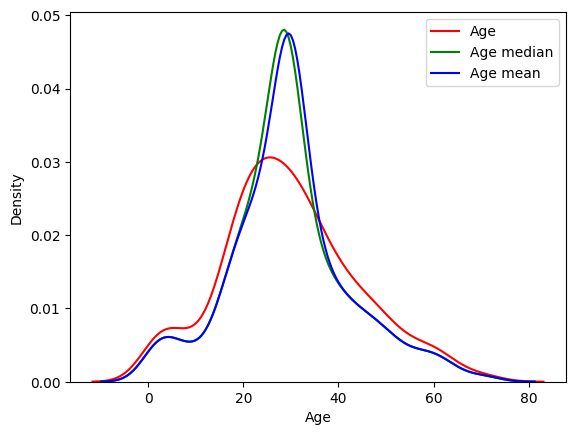

In [13]:
import seaborn as sns
fig, (ax1)=plt.subplots(nrows=1,ncols=1)
sns.kdeplot(X_train['Age'],ax=ax1,color='red',label='Age')
sns.kdeplot(X_train['Age median'],ax=ax1,color='green',label='Age median')
sns.kdeplot(X_train['Age mean'],ax=ax1,color='blue',label='Age mean')
plt.legend()
plt.show()

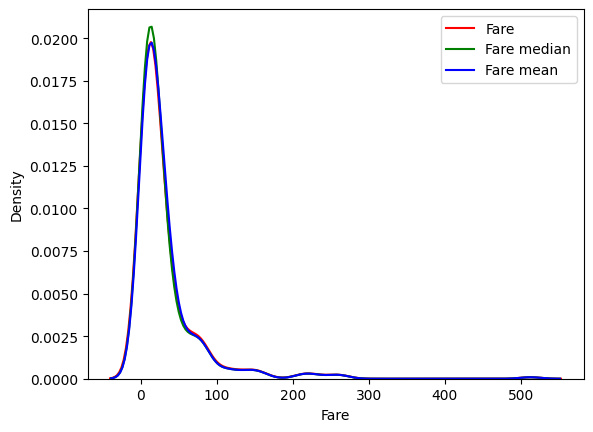

In [14]:
fig, (ax1)=plt.subplots(nrows=1,ncols=1)
sns.kdeplot(X_train['Fare'],ax=ax1,color='red',label='Fare')
sns.kdeplot(X_train['Fare median'],ax=ax1,color='green',label='Fare median')
sns.kdeplot(X_train['Fare mean'],ax=ax1,color='blue',label='Fare mean')
plt.legend()
plt.show()

In [15]:
X_train.cov()

,Age,Fare,Family,Age mean,Age median,Fare mean,Fare median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,64.858859
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.385048,16.476305
Age mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,51.358000
Age median,204.349513,57.957599,-5.112563,161.812625,161.989566,55.023037,53.553455
Fare mean,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526
Fare median,64.858859,2448.197914,16.476305,51.358000,53.553455,2324.238526,2340.091022


In [16]:
X_train.corr()

,Age,Fare,Family,Age mean,Age median,Fare mean,Fare median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.090156,0.087356
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,0.205499,0.205942
Age mean,1.000000,0.088069,-0.244610,1.000000,0.999454,0.086078,0.083461
Age median,1.000000,0.091757,-0.242883,0.999454,1.000000,0.089673,0.086982
Fare mean,0.090156,1.000000,0.205499,0.086078,0.089673,1.000000,0.996607
Fare median,0.087356,1.000000,0.205942,0.083461,0.086982,0.996607,1.000000


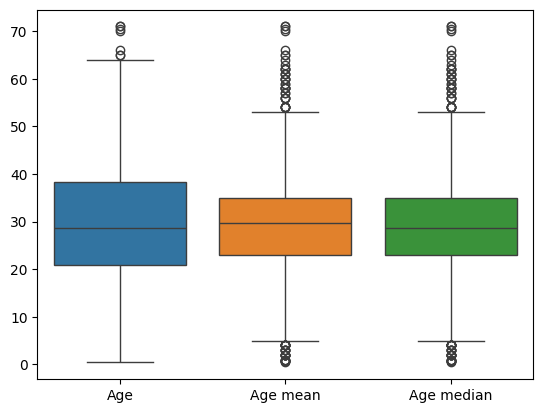

In [17]:
sns.boxplot((X_train['Age'],X_train['Age mean'],X_train['Age median']))
plt.show()

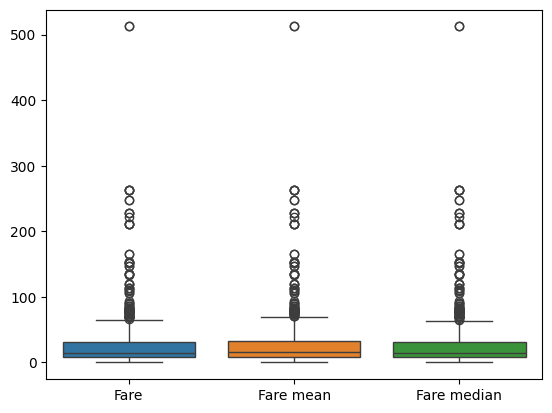

In [18]:
sns.boxplot((X_train['Fare'],X_train['Fare mean'],X_train['Fare median']))
plt.show()

<h3><b>Using sklearn

In [19]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [20]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [24]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [25]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [26]:
X_train=trf.transform(X_train)
X_test=trf.transform(X_test)

In [27]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))